In [1]:
import dtreeviz
import graphviz
print('dtreeviz import 성공')
print('graphviz import 성공')

dtreeviz import 성공
graphviz import 성공


In [2]:
import os
graphviz_bin = r'C:\Program Files\Graphviz\bin'
os.environ['PATH'] = graphviz_bin + os.pathsep + os.environ['PATH']

print(graphviz_bin)

C:\Program Files\Graphviz\bin


In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

mpl.rcParams['svg.fonttype'] = 'none'

In [4]:
import pandas as pd
import numpy as np
import time
from pathlib import Path
import warnings # 실행 중 나오는 경고메시지 정리 

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer # 컬럼종류별로 다른전처리를 적용하는 도구
from sklearn.pipeline import Pipeline # 전처리와 모델학습을 하나의 흐름으로 묶는 도구
from sklearn.preprocessing import OneHotEncoder # 범주형값을 숫자형으로 바꿈

from xgboost import XGBRegressor # 회귀용 XGBoost
warnings.filterwarnings('ignore')

In [5]:
warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('ggplot')

In [6]:
df = pd.read_csv('jeju_bus.csv')
display(df.head()) # print말고 노트북 출력 방식으로 dataframe출력
print('shape:', df.shape)
print('전체 결측치 수:', df.isnull().sum().sum())

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64


shape: (210457, 14)
전체 결측치 수: 0


In [7]:
df_model = df.copy()
df_model['original_index'] = df_model.index # 각 행의 원래 번호 저장. 예측결과를 원본행과 연결해서 오차 분석
target_col = 'next_arrive_time'

In [8]:
def prepare_features(df_input, required_cols, target_col):
    data = df_input.copy()
    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise ValueError(f'필수 컬럼이 누락되었습니다: {missing_cols}')
    
    data['date'] = pd.to_datetime(data['date']) # 날짜형 변환

    data['day'] = data['date'].dt.day
    data['dayofweek'] = data['date'].dt.dayofweek
    
    data['now_hour'] = (
        data['now_arrive_time'].astype(str).str.extract(r"(\d+)").astype(float) #extract목적이 한그룹만 뽑아서 변환이기때문에 괄호로 묶음
    )

    # data = data.drop(columns=['date', 'now_arrive_time'])
    #if target_col in data.columns:
    #    data = data.drop(columns=[target_col])
    # target_col써야돼서 유지
    # if 'id' in data.columns:
    #    data = data.drop(columns=['id'])
    return data

In [9]:
df_model = prepare_features(df_model, df.columns[1:-1], df.columns[-1])
# 만들어진 시간 feature 분포확인
df_model[['date', 'day', 'dayofweek', 'now_arrive_time', 'now_hour']].head()

,date,day,dayofweek,now_arrive_time,now_hour
0,2019-10-15,15,1,06시,6.0
1,2019-10-15,15,1,06시,6.0
2,2019-10-15,15,1,06시,6.0
3,2019-10-15,15,1,06시,6.0
4,2019-10-15,15,1,07시,7.0


In [10]:
df_model['station_segment'] = (
    df_model['now_station'].astype(str) + '->' + df_model['next_station'].astype(str)
)

df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time,original_index,day,dayofweek,now_hour,station_segment
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24,0,15,1,6.0,제주대학교입구->제대마을
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36,1,15,1,6.0,제대마을->제대아파트
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40,2,15,1,6.0,제대아파트->제주대학교
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42,3,15,1,6.0,남국원(아라방면)->제주여자중고등학교(아라방면)
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64,4,15,1,7.0,도호동->은남동


In [11]:
print('station_segment 고유값 개수:', df_model['station_segment'].nunique())
# nunique(): 서로 다른값이 몇종류인지 

station_segment 고유값 개수: 724


In [12]:
def calculate_distance_km(lat1, lon1, lat2, lon2):
    """
    위도/경도 사이 거리 km단위 계산
    numpy 기반 Haversine 계산 사용
    컬럼 전체 한번에 계산(벡터)
    """
    earth_radius_km = 6371

    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))
    return earth_radius_km * c

In [13]:
reference_points = {
    'up':     (33.506286, 126.490312),
    'right':  (33.493521, 126.895326),
    'center': (33.379724, 126.545315),
    'down':   (33.246742, 126.562387)
}

In [14]:
def assign_region_info(data, lat_col, lon_col):
    # 각 기준점 위도, 경도
    up_lat, up_lon = reference_points['up']
    down_lat, down_lon = reference_points['down']
    right_lat, right_lon = reference_points['right']
    center_lat, center_lon = reference_points['center']

    # 각 정류장에서 기준점까지 거리 계산
    distance_to_up = calculate_distance_km(data[lat_col], data[lon_col], up_lat, up_lon)
    distance_to_right = calculate_distance_km(data[lat_col], data[lon_col], down_lat, down_lon)
    distance_to_center = calculate_distance_km(data[lat_col], data[lon_col], right_lat, right_lon)
    distance_to_down = calculate_distance_km(data[lat_col], data[lon_col], center_lat, center_lon)

    # 거리 데이터 프레임 생성. 컬럼명을 저렇게 둬야 idxmin결과가 권역 이름이 됨
    distance_table = pd.DataFrame({
        'up': distance_to_up,
        'down': distance_to_down,
        'right': distance_to_right,
        'center': distance_to_center
    }, index=data.index)

    # 각행에서 가장 가까운 기준점 이름 찾기
    nearest_region = distance_table.idxmin(axis=1)

    # 최종 반환용 데이터 프레임
    result = pd.DataFrame({
        'dist_name': nearest_region,
        'dist_to_up': distance_to_up,
        'dist_to_down': distance_to_down,
        'dist_to_right': distance_to_right,
        'dist_to_center': distance_to_center    
        }, index=data.index)
    return result

In [15]:
# 현재 정류장 기준 권역 정보
now_region_info = assign_region_info(df_model, 'now_latitude', 'now_longitude')
now_region_info.head()

,dist_name,dist_to_up,dist_to_down,dist_to_right,dist_to_center
0,up,7.962505,8.532122,23.319056,32.135034
1,up,8.003869,8.710701,23.473015,31.905930
2,up,8.158338,8.861671,23.582519,31.583874
3,up,5.774762,11.118256,25.961685,32.635035
4,up,2.332803,12.673969,27.295447,37.141639


In [16]:
# 다음 정류장 기준 권역 정보
next_region_info = assign_region_info(
    df_model,
    'next_latitude',
    'next_longitude'
)
next_region_info.head()

,dist_name,dist_to_up,dist_to_down,dist_to_right,dist_to_center
0,up,8.003869,8.710701,23.473015,31.905930
1,up,8.158338,8.861671,23.582519,31.583874
2,up,8.387595,9.041978,23.701416,31.175511
3,up,5.429627,11.692688,26.539110,32.693959
4,up,2.276139,12.832868,27.400941,37.514443


In [17]:
df_model['now_dist_name'] = now_region_info['dist_name']
df_model['now_dist_to_up'] = now_region_info['dist_to_up']
df_model['now_dist_to_down'] = now_region_info['dist_to_down']
df_model['now_dist_to_right'] = now_region_info['dist_to_right']
df_model['now_dist_to_center'] = now_region_info['dist_to_center']

df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,...,original_index,day,dayofweek,now_hour,station_segment,now_dist_name,now_dist_to_up,now_dist_to_down,now_dist_to_right,now_dist_to_center
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,...,0,15,1,6.0,제주대학교입구->제대마을,up,7.962505,8.532122,23.319056,32.135034
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,...,1,15,1,6.0,제대마을->제대아파트,up,8.003869,8.710701,23.473015,31.905930
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,...,2,15,1,6.0,제대아파트->제주대학교,up,8.158338,8.861671,23.582519,31.583874
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,...,3,15,1,6.0,남국원(아라방면)->제주여자중고등학교(아라방면),up,5.774762,11.118256,25.961685,32.635035
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,...,4,15,1,7.0,도호동->은남동,up,2.332803,12.673969,27.295447,37.141639


In [18]:
df_model['next_dist_name'] = next_region_info['dist_name']
df_model['next_dist_to_up'] = next_region_info['dist_to_up']
df_model['next_dist_to_down'] = next_region_info['dist_to_down']
df_model['next_dist_to_right'] = next_region_info['dist_to_right']
df_model['next_dist_to_center'] = next_region_info['dist_to_center']

df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,...,now_dist_name,now_dist_to_up,now_dist_to_down,now_dist_to_right,now_dist_to_center,next_dist_name,next_dist_to_up,next_dist_to_down,next_dist_to_right,next_dist_to_center
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,...,up,7.962505,8.532122,23.319056,32.135034,up,8.003869,8.710701,23.473015,31.905930
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,...,up,8.003869,8.710701,23.473015,31.905930,up,8.158338,8.861671,23.582519,31.583874
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,...,up,8.158338,8.861671,23.582519,31.583874,up,8.387595,9.041978,23.701416,31.175511
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,...,up,5.774762,11.118256,25.961685,32.635035,up,5.429627,11.692688,26.539110,32.693959
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,...,up,2.332803,12.673969,27.295447,37.141639,up,2.276139,12.832868,27.400941,37.514443


In [19]:
# 현재 정류장 권역과 다음 정류장 권역 조합
df_model['dist_segment_name'] = (
    df_model['now_dist_name'].astype(str) + '->' + df_model['next_dist_name'].astype(str)
)

print('dist_segment_name 고유값 개수:', df_model['dist_segment_name'].nunique())
df_model['dist_segment_name'].value_counts().head()

dist_segment_name 고유값 개수: 12


dist_segment_name
up->up            121131
right->right       48377
center->center     34032
down->down          5512
down->up             321
Name: count, dtype: int64

In [20]:
# 최종후보 feature
selected_numeric_features = [
    'distance', 'day', 'dayofweek', 'now_hour', 'now_dist_to_up', 'now_dist_to_down', 'now_dist_to_right', 'now_dist_to_center',
    'next_dist_to_up', 'next_dist_to_down', 'next_dist_to_right', 'next_dist_to_center'
]
selected_categorical_features = [
    'route_nm', 'now_station', 'next_station', 'dist_segment_name'
]

In [21]:
selected_features = selected_numeric_features + selected_categorical_features
selected_features

['distance',
 'day',
 'dayofweek',
 'now_hour',
 'now_dist_to_up',
 'now_dist_to_down',
 'now_dist_to_right',
 'now_dist_to_center',
 'next_dist_to_up',
 'next_dist_to_down',
 'next_dist_to_right',
 'next_dist_to_center',
 'route_nm',
 'now_station',
 'next_station',
 'dist_segment_name']

In [22]:
upper_1pct = df_model[target_col].quantile(0.99)
upper_1pct

np.float64(340.0)

In [23]:
# 이상치 제외
df_model_selected = df_model[df_model[target_col] <= upper_1pct].copy()
len(df_model), len(df_model_selected), len(df_model) - len(df_model_selected), upper_1pct

(210457, 208355, 2102, np.float64(340.0))

In [24]:
X = df_model_selected[selected_features]
y = df_model_selected[target_col]
# 데이터셋 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((166684, 16), (41671, 16))

In [25]:
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), selected_categorical_features)],
    remainder='passthrough'
)

In [26]:
def evaluate_regression_model(model_name, description, y_true, y_pred):
    """
    회귀모델 예측결과 평가해서 딕셔너리로 반환
    MAE, RMSE
    directly_comparable : 이모델을 기준 베이스라인 모델과 직접 비교해도 되는지 표시. 평가에 사용한 데이터가 다르면 단순비교 X
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'[{model_name}] MAE: {mae:.4f} | RMSE: {rmse:.4f} ')
    # 여러 모델 결과를 표로 모으기 좋게 딕셔너리로 반환
    return {
        'model_name': model_name, 'description': description, 'MAE': mae, 'RMSE': rmse
}

In [27]:
def train_xgb_pipeline(model_name, description, xgb_params):
    """
    XGBoost모델 학습하고 평가하는 함수
    feature목록을 바꿔서 성능 변화 비교
    experiment : feature구성 설명
    """
    xgb_model = XGBRegressor(
        objective='reg:squarederror', # 제곱오차 줄이기
        random_state=42,              # 재현성 확보
        n_jobs=-1,                    # 가용 cpu 최대 사용
        **xgb_params                  # 실험마다 달라지는 하이퍼 파라미터
    )

    model_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', xgb_model)])
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)

    evaluation = evaluate_regression_model(model_name, description, y_test, y_pred)
    # 이후 오차분석 활용하기 위해 파이프라인, 평가결과, 예측값 반환 
    return {'model_name': model_name, 'pipeline': model_pipeline, 'evaluation':evaluation}

In [28]:
# 기준모델 하이퍼파라미터 설정
base_params = {
    'n_estimators': 200,
    'learning_rate': 0.05,
    'max_depth': 5
}

selected_base_result = train_xgb_pipeline(
    model_name='selected_base_xgb',
    description='선정 조건 기준 모델 (v2 + 위치 feature + 상위 1% 제거, 기본 파라미터)',
    xgb_params=base_params
)

[selected_base_xgb] MAE: 22.0203 | RMSE: 30.3539 


In [29]:
# 1. shallow_xgb: 깊이를 3으로 줄인 모델
shallow_result = train_xgb_pipeline(
    model_name='shallow_xgb',
    description='얇은 트리 (max_depth=3)',
    xgb_params={'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3}
)

[shallow_xgb] MAE: 24.6185 | RMSE: 33.1101 


In [30]:
# 2. deep_xgb: 깊이를 8로 늘린 모델
deep_result = train_xgb_pipeline(
    model_name='deep_xgb',
    description='깊은 트리 (max_depth=8) - 복잡한 모델',
    xgb_params={'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 8}
)

[deep_xgb] MAE: 19.7910 | RMSE: 28.3630 


In [31]:
# 3. slow_learning_xgb: 학습률 낮추고 트리수 늘린 모델
shallow_result = train_xgb_pipeline(
    model_name='slow_learning_xgb',
    description='천천히 많이 학습 (lr=0.03, n_estimators=400)',
    xgb_params={'n_estimators': 400, 'learning_rate': 0.03, 'max_depth': 5}
)

[slow_learning_xgb] MAE: 21.8065 | RMSE: 30.1558 


In [32]:
# 샘플링 + 규제 -> 과적합 완화
regularized_result = train_xgb_pipeline(
    model_name='regularized_xgb',
    description='과적합 완화 (subsample/colsample + reg_alpha/reg_lambda)',
    xgb_params={
        'n_estimators': 500,
        'learning_rate': 0.05,
        'max_depth': 8,
        'subsample': 0.8,        # 트리마다 행의 80%만 랜덤하게 매번 다르게 선택해서 사용
        'colsample_bytree': 0.8, # 트리마다 feature의 80%만 랜덤하게 매번 다르게 선택해서 사용
        'reg_alpha': 0.01,       # L1 규제
        're_lambda': 1.5         # L2 규제
    }
)

[regularized_xgb] MAE: 19.1292 | RMSE: 27.8428 


In [33]:
X_fold = pd.DataFrame({'feature_1': [1, 2, 3, 4, 5]})
y_fold = pd.Series([2, 4, 6, 8, 10], name='target')

In [34]:
from sklearn.model_selection import KFold

In [35]:
kf = KFold(n_splits=5, shuffle=False)

In [36]:
num = 1

In [37]:
# for train_idx, valid_idx in kf.split(X_fold):
#     print('=' * 30)
#     print(f'num={num}')
#     print(f'train_idx={train_idx}')
#     print(f'valid_idx={valid_idx}')
#     X_train = X_fold.iloc[train_idx]
#     y_train = y_fold.iloc[train_idx]
#     print(f'X_train={X_train}'); print(f'y_train={y_train}')
#     X_valid = X_fold.iloc[valid_idx]
#     y_valid = y_fold.iloc[valid_idx]
#     print(f'X_valid={X_valid}'); print(f'y_valid={y_valid}')
#     model = XGBRegressor()
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_valid)

#     mae = mean_absolute_error(y_valid, y_pred)
#     print(f'>>> Fold {num} MAE = {mae:.4f}')
#     num += 1

In [38]:
# 하이퍼파라미터 자동 튜닝
param_distributions = {
    'model__n_estimators':[400, 500],
    'model__learning_rate':[0.03, 0.05, 0.1],
    'model__max_depth':[8, 9, 10],
    'model__subsample':[0.8, 0.9, 1.0],
    'model__colsample_bytree':[0.8, 0.9, 1.0]
}
# MAE는 작을수록 좋으므로 음수 MAE사용
scoring = 'neg_mean_absolute_error'

len(param_distributions)

5

In [39]:
# 탐색에 사용할 pipeline. 
search_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=1 # 중첩 병렬 방지 randomizedsearchcv가 병렬 담당
    ))
])

In [40]:
# random 튜닝 구성
random_search = RandomizedSearchCV(
    estimator=search_model,
    param_distributions=param_distributions,
    n_iter=25,                          # 시도할 조합수  
    scoring='neg_mean_absolute_error',  # 음수 MAE
    cv=5,                               # train을 5개로 나눠서 내부 교차검증
    random_state=42,                    # 재현성
    n_jobs=-1,                          # 조합단위 병렬
    verbose=1                           # 진행상황출력
)


In [41]:
start_time = time.time()
random_search.fit(X_train, y_train)
elapsed = time.time() - start_time
elapsed

Fitting 5 folds for each of 25 candidates, totalling 125 fits


183.66676115989685

In [42]:
random_search.best_params_

{'model__subsample': 0.9,
 'model__n_estimators': 500,
 'model__max_depth': 9,
 'model__learning_rate': 0.1,
 'model__colsample_bytree': 0.9}

In [43]:
random_search.best_score_

np.float64(-18.76903381347656)

In [44]:
# 내부 교차 검증 MAE
best_cv_mae = -random_search.best_score_
best_cv_mae

np.float64(18.76903381347656)

In [45]:
best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)

best_result = evaluate_regression_model(
    model_name='best_tuned_xgb',
    description='RandomizedSearchCV로 선택한 최적 XGBoost 모델',
    y_true=y_test,
    y_pred=y_pred_best
)

print(f"best_cv_mae (train 내부 교차검증): {best_cv_mae:.4f}")
print(f"test MAE (남겨둔 test set): {best_result['MAE']:.4f}")

[best_tuned_xgb] MAE: 18.6961 | RMSE: 27.8832 
best_cv_mae (train 내부 교차검증): 18.7690
test MAE (남겨둔 test set): 18.6961


In [46]:
best_pred_compare_df = pd.DataFrame({
    'actual': y_test.values,
    'pred': y_pred_best,
    'error': y_test.values - y_pred_best,
    'abs_error': np.abs(y_test.values - y_pred_best)
})

In [47]:
best_pred_compare_df.sort_values('abs_error', ascending=False).head(20)

,actual,pred,error,abs_error
8003,300,46.430492,253.569508,253.569508
1910,340,111.353378,228.646622,228.646622
41213,320,91.770447,228.229553,228.229553
8852,320,91.977013,228.022987,228.022987
33792,310,88.804962,221.195038,221.195038
1045,288,67.401329,220.598671,220.598671
9496,82,301.209198,-219.209198,219.209198
35780,64,281.229187,-217.229187,217.229187
27804,328,117.912819,210.087181,210.087181
13709,308,99.951584,208.048416,208.048416


In [48]:
best_preprocessor = best_model.named_steps['preprocessor']
best_xgb_model = best_model.named_steps['model']

print('최적 모델 Pipeline 단계: ', list(best_model.named_steps.keys()))

최적 모델 Pipeline 단계:  ['preprocessor', 'model']


In [49]:
transformed_feature_names = best_preprocessor.get_feature_names_out()

print('전처리 후 feature 개수:', len(transformed_feature_names))
print('XGBoost feature importance 개수:', len(best_xgb_model.feature_importances_))

전처리 후 feature 개수: 743
XGBoost feature importance 개수: 743


In [50]:
feature_importance_df = pd.DataFrame({
    'feature': transformed_feature_names,
    'importance': best_xgb_model.feature_importances_,
})
feature_importance_df = feature_importance_df.sort_values(
    'importance', ascending=False
).reset_index(drop=True)

display(feature_importance_df.head(20))

,feature,importance
0,cat__next_station_제주중앙여자고등학교(아라방면),0.073370
1,remainder__next_dist_to_up,0.040864
2,cat__next_station_제주중앙여자고등학교(광양방면),0.036782
3,cat__now_station_성산환승정류장(고성리 회전교차로),0.033726
4,cat__next_station_성판악,0.030388
5,remainder__distance,0.030088
6,cat__now_station_원노형,0.029729
7,cat__dist_segment_name_up->up,0.027137
8,cat__now_station_농협 하나로마트,0.023208
9,cat__now_station_월성 마을,0.019446


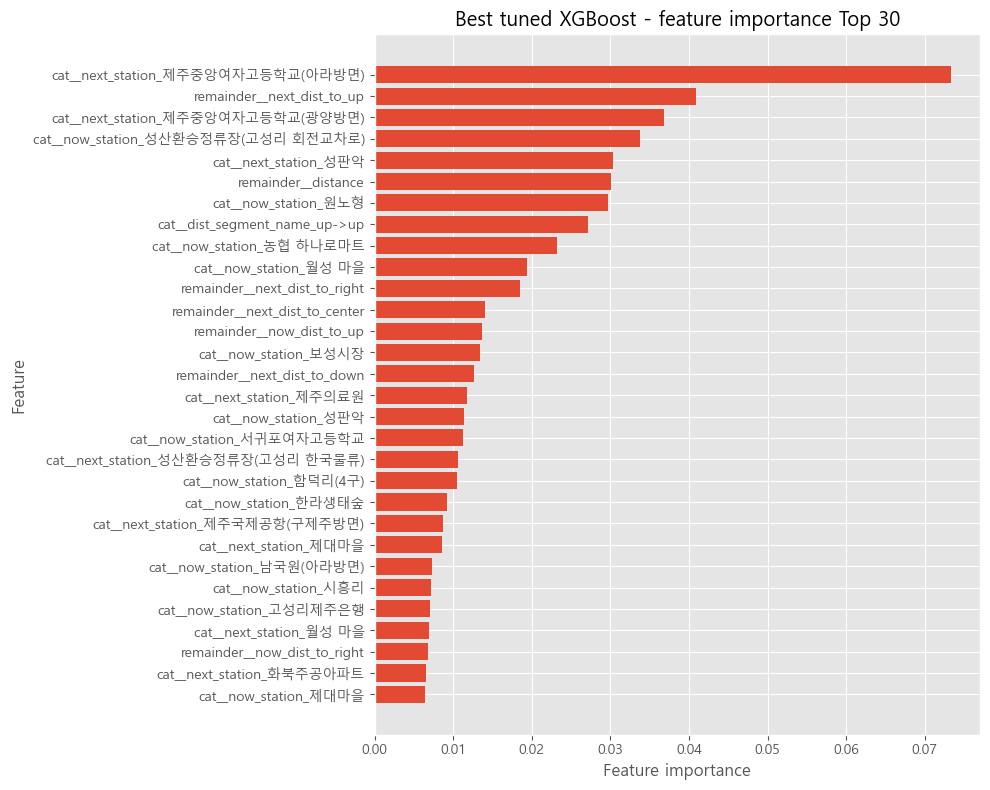

In [51]:
top_n = 30
top_importance_df = feature_importance_df.head(top_n).sort_values('importance')

plt.figure(figsize=(10, 8))
plt.barh(top_importance_df['feature'], top_importance_df['importance'])
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.title('Best tuned XGBoost - feature importance Top 30')
plt.tight_layout()

In [52]:
def get_original_feature_name(transformed_name, categorical_features, numeric_features):
    """
    OneHotEncoder 이후의 feature 이름을 원래대로 되돌리는 함수
    """
    # 접두어 떼고 원래 어느 컬럼인지 확인
    if transformed_name.startswith('cat__'):
        name = transformed_name.replace('cat__', '', 1)
        for col in categorical_features:
            if name == col or name.startswith(col + '_'):
                return col
        return name

    if transformed_name.startswith('remainder__'):
        return transformed_name.replace('remainder__', '', 1)
    
    return transformed_name


In [53]:
# 각 세부 feature 가 어디에서 나왔는지 표시한 후 원래 feature 단위로 중요도를 합산
if len(transformed_feature_names) == len(best_xgb_model.feature_importances_):
    feature_importance_df['original_feature'] = feature_importance_df['feature'].apply(
        lambda x: get_original_feature_name(
            x,
            selected_categorical_features,
            selected_numeric_features
        )
    )
    grouped_importance_df = (
        feature_importance_df
        .groupby('original_feature', as_index=False)['importance']
        .sum()
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )
    display(grouped_importance_df)

,original_feature,importance
0,now_station,0.425300
1,next_station,0.386805
2,next_dist_to_up,0.040864
3,dist_segment_name,0.036322
4,distance,0.030088
5,next_dist_to_right,0.018463
6,next_dist_to_center,0.014014
7,now_dist_to_up,0.013684
8,next_dist_to_down,0.012623
9,now_dist_to_right,0.006749


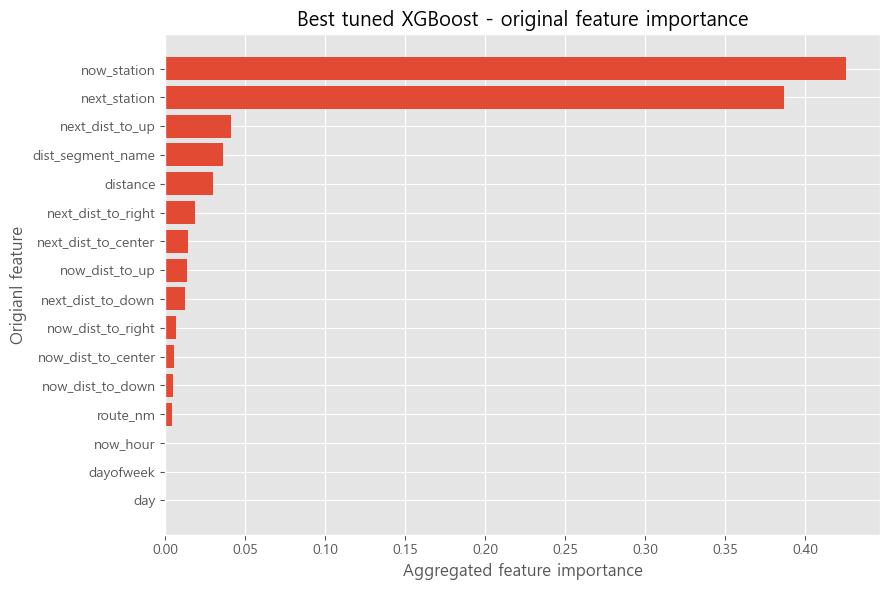

In [54]:
if len(transformed_feature_names) == len(best_xgb_model.feature_importances_):
    plot_grouped_df = grouped_importance_df.sort_values('importance')

    plt.figure(figsize=(9, 6))
    plt.barh(plot_grouped_df['original_feature'], plot_grouped_df['importance'])
    plt.xlabel('Aggregated feature importance')
    plt.ylabel('Origianl feature')
    plt.title('Best tuned XGBoost - original feature importance')
    plt.tight_layout()

In [55]:
# dtreeviz 활용 트리구조 시각화
# 폰트 폴더 설정
os.environ['GDFONTPATH'] = r'C:\Windows\Fonts'
output_dir = 'outputs'
os.makedirs(output_dir, exist_ok=True)

tree_index = 0
dtreeviz_svg_path = os.path.join(
    output_dir,
    f'xgboost_dtreeviz_tree_{tree_index}.svg'
)

dtreeviz_svg_path

'outputs\\xgboost_dtreeviz_tree_0.svg'

In [56]:
transformed_feature_names = list(best_preprocessor.get_feature_names_out())
transformed_feature_names

['cat__route_nm_201-11',
 'cat__route_nm_201-12',
 'cat__route_nm_201-13',
 'cat__route_nm_201-14',
 'cat__route_nm_201-15',
 'cat__route_nm_201-16',
 'cat__route_nm_201-17',
 'cat__route_nm_201-18',
 'cat__route_nm_201-21',
 'cat__route_nm_201-22',
 'cat__route_nm_201-24',
 'cat__route_nm_201-26',
 'cat__route_nm_201-27',
 'cat__route_nm_281-1',
 'cat__route_nm_281-2',
 'cat__route_nm_360-1',
 'cat__route_nm_360-12',
 'cat__route_nm_360-2',
 'cat__route_nm_360-7',
 'cat__route_nm_365-21',
 'cat__route_nm_365-22',
 'cat__now_station_911의원',
 'cat__now_station_LH아파트',
 'cat__now_station_가마초등학교',
 'cat__now_station_가흥동',
 'cat__now_station_거로 입구',
 'cat__now_station_견월교',
 'cat__now_station_계룡동',
 'cat__now_station_고도농원',
 'cat__now_station_고래왓',
 'cat__now_station_고망난돌입구',
 'cat__now_station_고산동산(광양방면)',
 'cat__now_station_고산동산(아라방면)',
 'cat__now_station_고성리 구 성산농협',
 'cat__now_station_고성리 성산농협',
 'cat__now_station_고성리제주은행',
 'cat__now_station_고성오일시장',
 'cat__now_station_고으니모르 국립제주박물관',

In [57]:
short_feature_names = []

for name in transformed_feature_names:
    short_name = (
        name
        .replace('cat__route_nm', 'route_')
        .replace('cat__now_station_', 'now_')
        .replace('cat__next_station_', 'next_')
        .replace('cat__dist_segment_name_', 'segment_')
        .replace('remainder__', '')
    )
    short_feature_names.append(short_name)
short_feature_names

['route__201-11',
 'route__201-12',
 'route__201-13',
 'route__201-14',
 'route__201-15',
 'route__201-16',
 'route__201-17',
 'route__201-18',
 'route__201-21',
 'route__201-22',
 'route__201-24',
 'route__201-26',
 'route__201-27',
 'route__281-1',
 'route__281-2',
 'route__360-1',
 'route__360-12',
 'route__360-2',
 'route__360-7',
 'route__365-21',
 'route__365-22',
 'now_911의원',
 'now_LH아파트',
 'now_가마초등학교',
 'now_가흥동',
 'now_거로 입구',
 'now_견월교',
 'now_계룡동',
 'now_고도농원',
 'now_고래왓',
 'now_고망난돌입구',
 'now_고산동산(광양방면)',
 'now_고산동산(아라방면)',
 'now_고성리 구 성산농협',
 'now_고성리 성산농협',
 'now_고성리제주은행',
 'now_고성오일시장',
 'now_고으니모르 국립제주박물관',
 'now_공업단지 입구',
 'now_공천포',
 'now_관덕정',
 'now_광대왓',
 'now_광양',
 'now_광양사거리',
 'now_광지동',
 'now_광치기해변',
 'now_교래입구',
 'now_구 터미널',
 'now_구좌보건지소',
 'now_구좌중앙초등학교',
 'now_국립제주박물관',
 'now_그린카센터',
 'now_금붕사',
 'now_금산목',
 'now_김녕리',
 'now_김녕해수욕장',
 'now_김녕환승정류장(김녕초등학교)',
 'now_꽃동산',
 'now_난산입구',
 'now_난산입구(성산기상대)',
 'now_남국사',
 'now_남국원(광양방면)',
 'now_남국원(아라방면)',
 'now_남

In [58]:
# 학습 데이터 생성
X_train_transformed = best_preprocessor.transform(X_train)

X_train_transformed = X_train_transformed.toarray()

X_train_viz_df = pd.DataFrame(
    X_train_transformed,
    columns=short_feature_names,
    index=X_train.index
)
'dtreeviz용 학습 데이터 shape:', X_train_viz_df.shape

('dtreeviz용 학습 데이터 shape:', (166684, 743))

In [ ]:
# 기존 최적 파라미터 가져오기
best_xgb_params = best_xgb_model.get_params()

viz_xgb_model = XGBRegressor(**best_xgb_params)

In [105]:
# 시각화 전용 모델 학습
viz_xgb_model.fit(
    X_train_viz_df,
    y_train
)

print('dtreeviz용 XGBoost 모델 학습 완료')
print('booster feature_names 예시:')
print(viz_xgb_model.get_booster().feature_names[:20])

dtreeviz용 XGBoost 모델 학습 완료
booster feature_names 예시:
['route__201-11', 'route__201-12', 'route__201-13', 'route__201-14', 'route__201-15', 'route__201-16', 'route__201-17', 'route__201-18', 'route__201-21', 'route__201-22', 'route__201-24', 'route__201-26', 'route__201-27', 'route__281-1', 'route__281-2', 'route__360-1', 'route__360-12', 'route__360-2', 'route__360-7', 'route__365-21']


In [ ]:
# dtreeviz용 샘플 데이터 준비
sample_size = min( 1000, len(X_train_viz_df))

X_train_viz_sample = X_train_viz_df.sample(
    n=sample_size,
    random_state=42
)

y_train_viz_sample = y_train.loc[X_train_viz_sample.index]

print('dtreeviz 시각화용 샘플 수:', len(X_train_viz_sample))

dtreeviz 시각화용 샘플 수: 1000


In [110]:
from dtreeviz import model as dtreeviz_model

viz = dtreeviz_model(
    viz_xgb_model,
    X_train_viz_sample,
    y_train_viz_sample,
    feature_names=list(X_train_viz_sample.columns),
    target_name=target_col,
    tree_index=tree_index,
)

In [111]:
# SVG 저장
viz_render = viz.view()
viz_render.save(dtreeviz_svg_path)

print('dtreeviz SVG 저장완료:')
print(os.path.abspath(dtreeviz_svg_path))

dtreeviz SVG 저장완료:
d:\code\ai_project01\outputs\xgboost_dtreeviz_tree_0.svg


In [ ]:
# 파일 내부에 한글 폰트 스타일 삽입
svg_file = Path(dtreeviz_svg_path)
svg_text = svg_file.read_text(encoding='utf-8')

korean_font_style = """
<style>
text {
font-family: "Malgun Gothic", "맑은 고딕", "Noto Sans CJK KR", sans-serif !important;
}
</style> 
"""

insert_pos = svg_text.find('>') + 1
svg_text = svg_text[:insert_pos] + korean_font_style + svg_text[insert_pos:]

svg_file.write_text(svg_text, encoding='utf-8')
print('SVG 파일에 한글 폰트 스타일을 추가했습니다.')

SVG 파일에 한글 폰트 스타일을 추가했습니다.
